c:\Users\sirju\AppData\Local\Programs\Python\Python310\lib\site-packages\upsetplot\data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
c:\Users\sirju\AppData\Local\Programs\Python\Python310\lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original objec

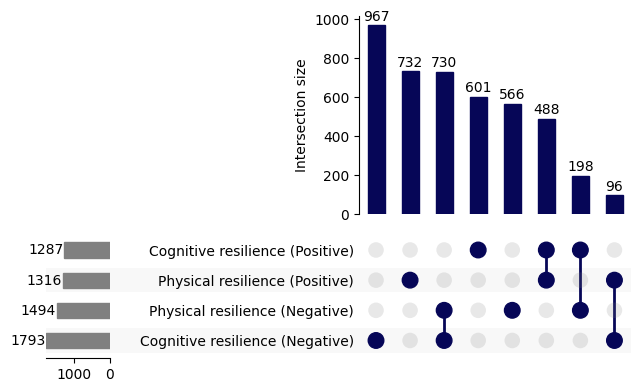

Done!


In [2]:
#Figure S3a
### Physical resilience & Cognitive resilience upset plot

import pandas as pd
from upsetplot import UpSet, from_contents
import matplotlib.pyplot as plt

# Load files
phys = pd.read_csv(r"C:\Users\sirju\OneDrive\Desktop\AgingPaper2\For_github\SupplementaryFigureS3\0-ranked_metabolites-physres_with_compound.csv")
cog  = pd.read_csv(r"C:\Users\sirju\OneDrive\Desktop\AgingPaper2\For_github\SupplementaryFigureS3\ranked_metabolites_cognitive_resilience_updated.csv")

# Split metabolites by Direction
pos_phys = set(phys.loc[phys["Direction_physical"] == "Positive", "Metabolite_physical"].dropna())
neg_phys = set(phys.loc[phys["Direction_physical"] == "Negative", "Metabolite_physical"].dropna())
pos_cog  = set(cog.loc[cog["Direction"] == "Positive", "Metabolite"].dropna())
neg_cog  = set(cog.loc[cog["Direction"] == "Negative", "Metabolite"].dropna())

# Build UpSet plot data
contents = {
    "Physical resilience (Positive)": pos_phys,
    "Physical resilience (Negative)": neg_phys,
    "Cognitive resilience (Positive)": pos_cog,
    "Cognitive resilience (Negative)": neg_cog,
}

data = from_contents(contents)

# Plot
fig = plt.figure(figsize=(14, 6))

upset = UpSet(data, subset_size="count", show_counts=True, sort_by="cardinality",
              facecolor="gray")  # Default bar color

# Style each subset with navy color
for set_name in contents.keys():
    upset.style_subsets(present=set_name, facecolor="#060657")

upset.plot(fig=fig)

for ax in fig.axes:
    ax.grid(False)

# Change set label text colors
label_colors = {
    "Physical resilience (Positive)": "#000000",
    "Physical resilience (Negative)": "#000000",
    "Cognitive resilience (Positive)": "#000000",
    "Cognitive resilience (Negative)": "#000000",
}

# Check all axes for text labels
for ax in fig.axes:
    for text in ax.get_yticklabels():
        label = text.get_text()
        if label in label_colors:
            text.set_color(label_colors[label])
    # Also check text objects directly
    for text in ax.texts:
        label = text.get_text()
        if label in label_colors:
            text.set_color(label_colors[label])

# Save
plt.tight_layout()
plt.savefig(r"C:\Users\sirju\OneDrive\Desktop\AgingPaper2\For_github\SupplementaryFigureS3\upset_plot_cog_vs_phys.svg", bbox_inches="tight")
plt.show()
print("Done!")